# Agent-Based Wound Healing Simulation
### Section 1: Visualizing Scenarios with Reinfection and Healer Boost (Natural Immunity)

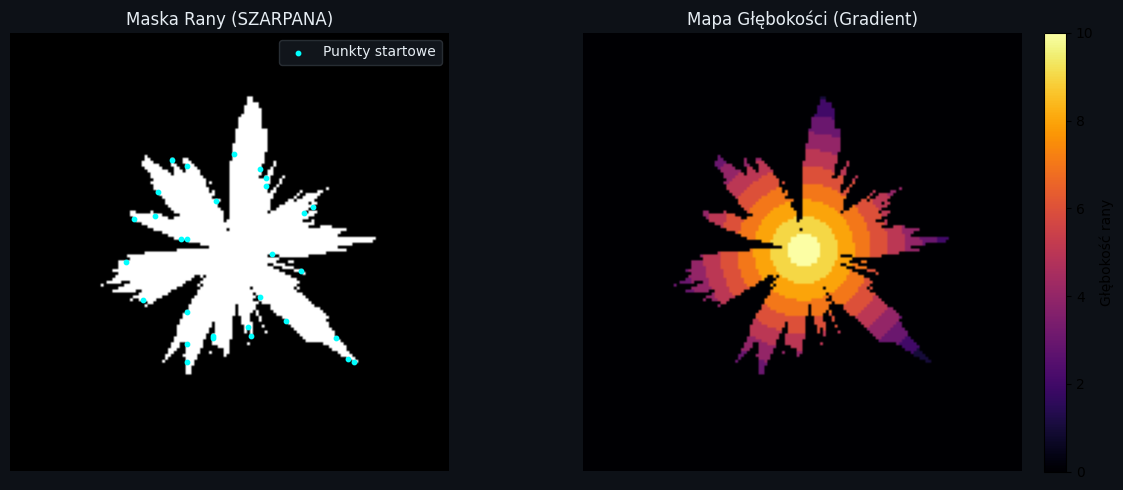

Pomyślnie wygenerowano geometrię rany typu: szarpana
Liczba komórek rany: 3098


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

# ==========================================
# KONFIGURACJA KSZTAŁTU RANY
# WOUND_TYPE może przyjmować wartości:
# 'kluta'    - rana na planie koła
# 'cieta'    - nieregularny, podłużny kształt (prostokąt)
# 'szarpana' - bardzo nieregularny, poszarpany kształt
# ==========================================
WOUND_TYPE = 'szarpana' 

# Jeśli te zmienne nie są zdefiniowane z poprzednich komórek, upewniamy się, że tu są:
grid_size = 150
true_center_xy = np.array([grid_size * 0.5, grid_size * 0.5])
n_spawn_points = 30
rng = np.random.default_rng(42) # Możesz zmienić ziarno (42) dla innych kształtów losowych

def polygon_to_mask(boundary_points_xy, size):
    yy, xx = np.mgrid[0:size, 0:size]
    all_pixels_xy = np.column_stack([xx.ravel(), yy.ravel()])
    return Path(boundary_points_xy).contains_points(all_pixels_xy).reshape(size, size)

def generate_puncture_wound(center, radius, size):
    """1. Rana kłuta - koło z delikatnie zaszumionymi krawędziami."""
    yy, xx = np.mgrid[0:size, 0:size]
    dist = np.sqrt((xx - center[0])**2 + (yy - center[1])**2)
    noise = rng.normal(0, 1.5, size=(size, size)) # Bardzo mały szum dla w miarę gładkich krawędzi
    return (dist + noise) <= radius

def generate_cut_wound(center, length, width, angle_deg, size):
    """2. Rana cięta - pochylony, zaszumiony, podłużny kształt (prostokąt)."""
    yy, xx = np.mgrid[0:size, 0:size]
    angle = np.deg2rad(angle_deg)
    
    # Przesunięcie do środka
    dx = xx - center[0]
    dy = yy - center[1]
    
    # Obrót współrzędnych
    rx = dx * np.cos(angle) - dy * np.sin(angle)
    ry = dx * np.sin(angle) + dy * np.cos(angle)
    
    # Szum dla poszarpanych brzegów cięcia
    noise_x = rng.normal(0, 3.0, size=(size, size))
    noise_y = rng.normal(0, 1.5, size=(size, size))
    
    # Sprawdzenie czy punkt leży wewnątrz prostokąta (z nałożonym szumem)
    return (np.abs(rx + noise_x) <= length / 2) & (np.abs(ry + noise_y) <= width / 2)

def generate_depth_map(mask, center_xy):
    """Tworzy mapę głębokości rany (od 1 na krawędziach do 10 w centrum)."""
    depth = np.zeros(mask.shape, dtype=float)
    yy, xx = np.mgrid[0:mask.shape[0], 0:mask.shape[1]]
    dist = np.sqrt((xx - center_xy[0])**2 + (yy - center_xy[1])**2)
    
    wound_dists = dist[mask]
    if len(wound_dists) > 0:
        min_d, max_d = np.min(wound_dists), np.max(wound_dists)
        for r in range(mask.shape[0]):
            for c in range(mask.shape[1]):
                if mask[r, c]:
                    # Odwracamy dystans, aby środek miał największą wartość
                    norm = (dist[r, c] - min_d) / (max_d - min_d + 1e-9)
                    d = 10.0 * (1.0 - norm)
                    depth[r, c] = np.clip(np.ceil(d), 1, 10)
    return depth.astype(int)

def generate_laceration_wound(center, base_radius, size):
    """3. Rana szarpana - bardzo nieregularny poligon z silnymi zniekształceniami."""
    angles = np.linspace(0, 2 * np.pi, 200, endpoint=True)
    # Nakładamy kilka mocnych fal sinusoidalnych, by stworzyć "szarpania" tkanki
    harmonic = 1 + 0.35 * np.sin(6 * angles) + 0.25 * np.cos(9 * angles) + 0.2 * np.sin(14 * angles)
    
    radius = base_radius * harmonic + rng.normal(0.0, 5.0, size=200)
    radius = np.clip(radius, base_radius * 0.2, base_radius * 2.0)
    
    boundary_points = np.column_stack([center[0] + radius * np.cos(angles), center[1] + radius * np.sin(angles)])
    return polygon_to_mask(boundary_points, size)

# ==========================================
# GENEROWANIE WYBRANEGO KSZTAŁTU
# ==========================================
if WOUND_TYPE == 'kluta':
    wound_mask = generate_puncture_wound(true_center_xy, radius=35, size=grid_size)
elif WOUND_TYPE == 'cieta':
    wound_mask = generate_cut_wound(true_center_xy, length=90, width=15, angle_deg=45, size=grid_size)
elif WOUND_TYPE == 'szarpana':
    wound_mask = generate_laceration_wound(true_center_xy, base_radius=30, size=grid_size)
else:
    raise ValueError("Nieznany typ rany. Wybierz 'kluta', 'cieta' lub 'szarpana'.")

# ==========================================
# PRZYGOTOWANIE ZMIENNYCH DLA SYMULACJI
# ==========================================
# Generowanie mapy głębokości (używamy funkcji z sekcji 1)
initial_depth_map = generate_depth_map(wound_mask, true_center_xy)

# Wyznaczanie krawędzi (do rozmieszczenia punktów startowych walkerów)
padded_mask = np.pad(wound_mask, 1)
boundary_mask = wound_mask & ~((padded_mask[:-2, 1:-1] & padded_mask[2:, 1:-1] & padded_mask[1:-1, :-2] & padded_mask[1:-1, 2:]))
boundary_cells_rc = np.argwhere(boundary_mask)

# Zabezpieczenie: jeśli obwód jest mniejszy niż liczba pożądanych punktów startowych
actual_spawns = min(n_spawn_points, len(boundary_cells_rc))
start_cells_rc = boundary_cells_rc[rng.choice(len(boundary_cells_rc), actual_spawns, replace=False)]

# ==========================================
# WIZUALIZACJA KONTROLNA WYGENEROWANEJ RANY
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="#0d1117")
for ax in axes: ax.axis("off")

axes[0].set_title(f"Maska Rany ({WOUND_TYPE.upper()})", color="#e6edf3")
axes[0].imshow(wound_mask, cmap='gray', origin='lower')
axes[0].scatter(start_cells_rc[:, 1], start_cells_rc[:, 0], c='cyan', s=10, label='Punkty startowe')
axes[0].legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#e6edf3")

axes[1].set_title("Mapa Głębokości (Gradient)", color="#e6edf3")
depth_plot = np.zeros_like(initial_depth_map, dtype=float)
depth_plot[wound_mask] = initial_depth_map[wound_mask]
im = axes[1].imshow(depth_plot, cmap='inferno', origin='lower')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Głębokość rany")

plt.tight_layout()
plt.show()

print(f"Pomyślnie wygenerowano geometrię rany typu: {WOUND_TYPE}")
print(f"Liczba komórek rany: {wound_mask.sum()}")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.colors as mcolors

# -- Dark-mode palette --
_BG        = "#0d1117"
_AXES_BG   = "#161b22"
_EDGE      = "#30363d"
_TEXT      = "#e6edf3"
_TICK      = "#8b949e"
_RED_HOT   = "#f85149"
_GREEN_HLD = "#196127"
_BLUE_WALK = "#58a6ff"
_YELLOW_INF = "#f1e05a"
_CYAN_WALK  = "#ff00ff"
# Nowe kolory dla gradientu głębokości rany
_WOUND_LIGHT = "#e06666" # Płytka
_WOUND_DARK  = "#2a0000" # Głęboka

plt.rcParams.update({
    "figure.facecolor":  _BG, "axes.facecolor": _AXES_BG, "axes.edgecolor": _EDGE,
    "axes.labelcolor": _TEXT, "axes.titlecolor": _TEXT, "text.color": _TEXT,
    "xtick.color": _TICK, "ytick.color": _TICK, "grid.color": _EDGE,
    "legend.facecolor": _AXES_BG, "legend.edgecolor": _EDGE,
    "savefig.facecolor": _BG, "axes.titlepad": 10,
})

# -- Shared Configuration --
grid_size = 150
num_steps = 1500
snapshot_every = 10
n_spawn_points = 30
walkers_per_spawn = 10
rng = np.random.default_rng(42)

def generate_noisy_boundary_points(center_xy, base_radius, n_points):
    angles = np.linspace(0, 2 * np.pi, n_points, endpoint=True)
    harmonic = 1 + 0.1 * np.sin(4 * angles) + 0.18 * np.sin(3 * angles)
    radius = np.clip(base_radius * harmonic + rng.normal(0.0, 3.0, size=n_points), base_radius * 0.45, base_radius * 1.45)
    return np.column_stack([center_xy[0] + radius * np.cos(angles), center_xy[1] + radius * np.sin(angles)])

def polygon_to_mask(boundary_points_xy, size):
    yy, xx = np.mgrid[0:size, 0:size]
    all_pixels_xy = np.column_stack([xx.ravel(), yy.ravel()])
    return Path(boundary_points_xy).contains_points(all_pixels_xy).reshape(size, size)

def generate_depth_map(mask, center_xy):
    """Tworzy mapę głębokości rany (od 1 na krawędziach do 10 w centrum)."""
    depth = np.zeros(mask.shape, dtype=float)
    yy, xx = np.mgrid[0:mask.shape[0], 0:mask.shape[1]]
    dist = np.sqrt((xx - center_xy[0])**2 + (yy - center_xy[1])**2)
    
    wound_dists = dist[mask]
    if len(wound_dists) > 0:
        min_d, max_d = np.min(wound_dists), np.max(wound_dists)
        for r in range(mask.shape[0]):
            for c in range(mask.shape[1]):
                if mask[r, c]:
                    # Odwracamy dystans, aby środek miał największą wartość
                    norm = (dist[r, c] - min_d) / (max_d - min_d + 1e-9)
                    d = 10.0 * (1.0 - norm)
                    depth[r, c] = np.clip(np.ceil(d), 1, 10)
    return depth.astype(int)

def run_simulation(mask, base_depth_map, start_cells_rc, n_steps, snapshot_every, healer_ratio, spread_chance, boost_chance=0.01):
    walkers = np.repeat(start_cells_rc, walkers_per_spawn, axis=0).astype(int)
    n_walkers = len(walkers)
    walker_roles = np.zeros(n_walkers, dtype=int)
    role_indices = rng.choice(n_walkers, int(n_walkers * healer_ratio), replace=False)
    walker_roles[role_indices] = 1
    
    depth_map = base_depth_map.copy()
    inf_cure_progress = np.zeros(mask.shape, dtype=int)
    healed = np.zeros(mask.shape, dtype=bool)
    infected = np.zeros(mask.shape, dtype=bool)
    
    wound_idx = np.argwhere(mask)
    infected[tuple(wound_idx[rng.choice(len(wound_idx), int(len(wound_idx)*0.02))].T)] = True
    
    snapshots = []
    offsets = np.array([[-1,-1],[-1,0],[-1,1],[0,-1],[0,1],[1,-1],[1,0],[1,1]])

    for step in range(n_steps):
        # 1. Spreading / Reinfection logic
        inf_r, inf_c = np.where(infected)
        for r, c in zip(inf_r, inf_c):
            if rng.random() < spread_chance:
                off = offsets[rng.integers(8)]
                nr, nc = r + off[0], c + off[1]
                if (0 <= nr < grid_size and 0 <= nc < grid_size and mask[nr, nc]):
                    infected[nr, nc] = True
                    healed[nr, nc] = False
                    if depth_map[nr, nc] == 0:
                        depth_map[nr, nc] = 1 # Infekcja lekko "otwiera" zagojoną tkankę

        # 2. Healer Boost Logic (Healthy cells help neighbors)
        healed_r, healed_c = np.where(healed)
        for r, c in zip(healed_r, healed_c):
            off = offsets[rng.integers(8)]
            nr, nc = r + off[0], c + off[1]
            if (0 <= nr < grid_size and 0 <= nc < grid_size and infected[nr, nc]):
                if rng.random() < boost_chance:
                    infected[nr, nc] = False

        # 3. Walker movement and action logic
        for i in range(n_walkers):
            pos = walkers[i]
            drift_vec = rng.normal(0, 0.5, size=2)
            candidates = pos + offsets
            valid = (candidates[:,0] >= 0) & (candidates[:,0] < mask.shape[0]) & \
                    (candidates[:,1] >= 0) & (candidates[:,1] < mask.shape[1])
            candidates = candidates[valid]
            candidates = candidates[mask[candidates[:,0], candidates[:,1]]]
            if len(candidates) > 0:
                scores = (candidates - pos) @ drift_vec
                walkers[i] = candidates[np.argmax(scores)]
            
            new_r, new_c = walkers[i]
            # Healerzy są 2x silniejsi w usuwaniu infekcji i tkanki (opcjonalny balans)
            walker_power = 2 if walker_roles[i] == 1 else 1
            
            if infected[new_r, new_c]:
                inf_cure_progress[new_r, new_c] += walker_power
                # Im głębsza rana, tym więcej wizyt potrzeba do usunięcia infekcji
                required_visits = max(1, int(depth_map[new_r, new_c] * 1.5))
                if inf_cure_progress[new_r, new_c] >= required_visits:
                    infected[new_r, new_c] = False
                    inf_cure_progress[new_r, new_c] = 0
            else:
                if depth_map[new_r, new_c] > 0:
                    depth_map[new_r, new_c] = max(0, depth_map[new_r, new_c] - walker_power)
                if depth_map[new_r, new_c] <= 0:
                    healed[new_r, new_c] = True

        if step % snapshot_every == 0:
            snapshots.append({'step': step, 'infected': infected.copy(), 'healed': healed.copy(), 'walkers': walkers.copy(), 'roles': walker_roles.copy(), 'depth': depth_map.copy()})
    return snapshots

def save_gif(snapshots, mask, filename, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    
    c_bg = np.array(mcolors.to_rgb(_BG))
    c_healed = np.array(mcolors.to_rgb(_GREEN_HLD))
    c_infected = np.array(mcolors.to_rgb(_YELLOW_INF))
    c_wound_light = np.array(mcolors.to_rgb(_WOUND_LIGHT))
    c_wound_dark = np.array(mcolors.to_rgb(_WOUND_DARK))
    
    def update(frame_idx):
        ax.clear()
        data = snapshots[frame_idx]
        depth = data['depth']
        infected = data['infected']
        healed = data['healed']
        
        # Wypełniamy obraz wektorowo na podstawie głębokości (gradient)
        img = np.full((mask.shape[0], mask.shape[1], 3), c_bg)
        wound_cells = mask & ~healed & ~infected
        
        d_vals = depth[wound_cells]
        ratio = np.clip((d_vals - 1) / 9.0, 0, 1) # Normalizacja głębokości od 0.0 do 1.0
        
        colors = (1 - ratio[:, None]) * c_wound_light + ratio[:, None] * c_wound_dark
        img[wound_cells] = colors
        img[infected] = c_infected
        img[healed] = c_healed
        
        ax.imshow(img, origin="lower")
        
        healers = data['walkers'][data['roles'] == 1]
        regulars = data['walkers'][data['roles'] == 0]
        ax.scatter(regulars[:, 1], regulars[:, 0], c=_BLUE_WALK, s=8, alpha=0.6)
        ax.scatter(healers[:, 1], healers[:, 0], c=_CYAN_WALK, s=20, edgecolors="white", linewidths=0.3)
        
        h_pct = (data['healed'].sum() / mask.sum()) * 100
        ax.set_title(f"{title}\nStep {data['step']} | Healed: {h_pct:.1f}% | Infected: {data['infected'].sum()}")
        ax.axis("off")
        
    anim = FuncAnimation(fig, update, frames=len(snapshots), interval=50)
    anim.save(filename, writer=PillowWriter(fps=15))
    plt.close(fig)

# -- Initialize Geometry --
# true_center_xy = np.array([grid_size * 0.52, grid_size * 0.50])
# boundary_points = generate_noisy_boundary_points(true_center_xy, grid_size*0.3, 150)
# wound_mask = polygon_to_mask(boundary_points, grid_size)
# initial_depth_map = generate_depth_map(wound_mask, true_center_xy)

# boundary_cells_rc = np.argwhere(wound_mask & ~((np.pad(wound_mask, 1)[:-2, 1:-1] & np.pad(wound_mask, 1)[2:, 1:-1] & np.pad(wound_mask, 1)[1:-1, :-2] & np.pad(wound_mask, 1)[1:-1, 2:])))
# start_cells_rc = boundary_cells_rc[rng.choice(len(boundary_cells_rc), n_spawn_points, replace=False)]

# Running Scenario 1
print("Running Scenario 1: Infection Wins...")
snaps_win = run_simulation(wound_mask, initial_depth_map, start_cells_rc, num_steps, snapshot_every, healer_ratio=0.1, spread_chance=0.02, boost_chance=0.01)
save_gif(snaps_win, wound_mask, "infection__wins.gif", "Scenario: Infection Wins")

# Running Scenario 2
print("Running Scenario 2: Infection Killed...")
snaps_kill = run_simulation(wound_mask, initial_depth_map, start_cells_rc, num_steps, snapshot_every, healer_ratio=0.5, spread_chance=0.02, boost_chance=0.01)
save_gif(snaps_kill, wound_mask, "infection__killed.gif", "Scenario: Infection Killed")
print("GIF animations successfully saved to disk!")

Running Scenario 1: Infection Wins...
Running Scenario 2: Infection Killed...
GIF animations successfully saved to disk!


Rozpoczynam symulacje dla 4 wariantów ruchu. To może chwilę potrwać...
-> Uruchamiam 1. Classical Random Walk...
-> Uruchamiam 2. Biased (Center) Random Walk...
-> Uruchamiam 3. Persistent Random Walk...
-> Uruchamiam 4. Local Preference Walk...
Zakończono! Renderowanie wykresów analitycznych...


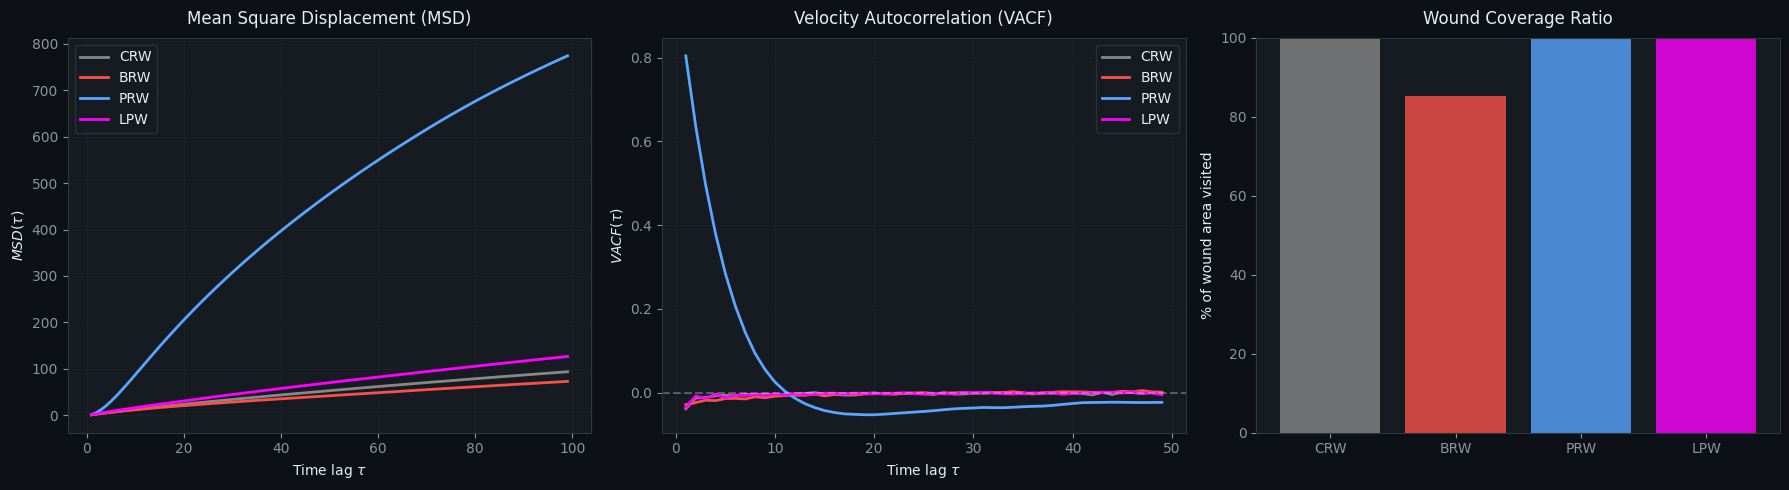

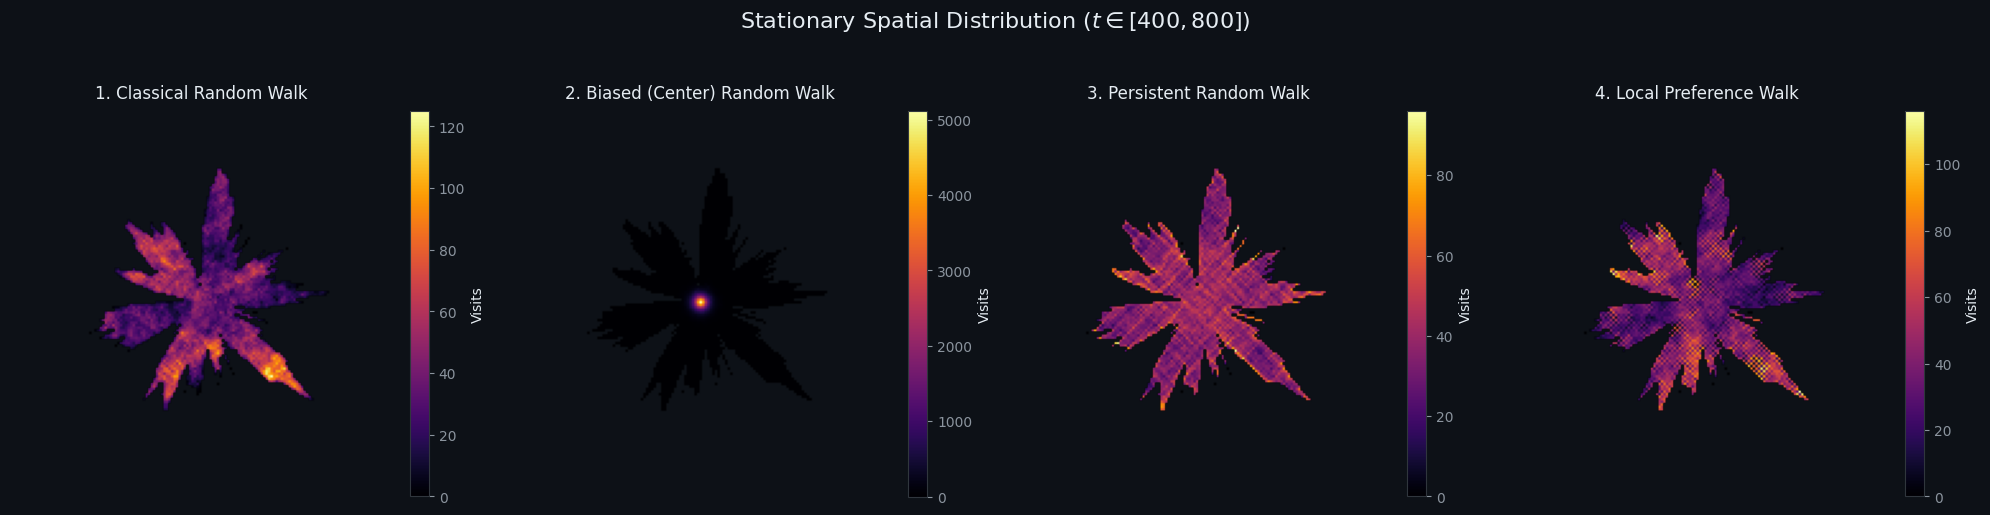

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def run_metric_simulation(mask, base_depth_map, start_cells_rc, n_steps, movement_type):
    # Inicjalizacja tak jak w bazowym scenariuszu
    walkers = np.repeat(start_cells_rc, walkers_per_spawn, axis=0).astype(int)
    n_walkers = len(walkers)
    walker_roles = np.zeros(n_walkers, dtype=int)
    role_indices = rng.choice(n_walkers, int(n_walkers * 0.5), replace=False) # Ustalone ratio healerów na 0.5
    walker_roles[role_indices] = 1
    
    depth_map = base_depth_map.copy()
    inf_cure_progress = np.zeros(mask.shape, dtype=int)
    healed = np.zeros(mask.shape, dtype=bool)
    infected = np.zeros(mask.shape, dtype=bool)
    
    wound_idx = np.argwhere(mask)
    infected[tuple(wound_idx[rng.choice(len(wound_idx), int(len(wound_idx)*0.02))].T)] = True
    
    offsets = np.array([[-1,-1],[-1,0],[-1,1],[0,-1],[0,1],[1,-1],[1,0],[1,1]])
    
    # Dodatkowe struktury dla metryk ruchu
    trajectories = np.zeros((n_steps, n_walkers, 2), dtype=int)
    prev_positions = walkers.copy()
    snapshots = []

    for step in range(n_steps):
        # 1. Spreading (Uproszczone z małą szansą, by skupić się na mechanice ruchu)
        inf_r, inf_c = np.where(infected)
        for r, c in zip(inf_r, inf_c):
            if rng.random() < 0.02:
                off = offsets[rng.integers(8)]
                nr, nc = r + off[0], c + off[1]
                if (0 <= nr < grid_size and 0 <= nc < grid_size and mask[nr, nc]):
                    infected[nr, nc] = True
                    healed[nr, nc] = False

        # 2. Ruch Walkerów z logiką 4 wariantów
        for i in range(n_walkers):
            pos = walkers[i]
            candidates = pos + offsets
            valid = (candidates[:,0] >= 0) & (candidates[:,0] < mask.shape[0]) & \
                    (candidates[:,1] >= 0) & (candidates[:,1] < mask.shape[1])
            candidates = candidates[valid]
            candidates = candidates[mask[candidates[:,0], candidates[:,1]]]

            if len(candidates) > 0:
                if movement_type == 'CRW':
                    # 1. Klasyczny Random Walk - w pełni losowy
                    chosen = candidates[rng.integers(len(candidates))]
                
                elif movement_type == 'BRW':
                                    # 2. Biased Random Walk - łagodna skłonność do pójścia w stronę centrum
                                    vec_to_center = true_center_xy - pos
                                    dist_to_center = np.linalg.norm(vec_to_center)
                                    
                                    if dist_to_center < 1e-3:
                                        # Jeśli agent jest w samym idealnym centrum, ruch w pełni losowy
                                        chosen = candidates[rng.integers(len(candidates))]
                                    else:
                                        # Znormalizowany wektor wskazujący środek rany
                                        vec_to_center_norm = vec_to_center / dist_to_center
                                        
                                        # Znormalizowane wektory potencjalnych kierunków ruchu
                                        move_vecs = candidates - pos
                                        move_norms = np.linalg.norm(move_vecs, axis=1)
                                        move_vecs_norm = move_vecs / move_norms[:, np.newaxis]
                                        
                                        # Iloczyn skalarny: 1 (idealnie w stronę centrum), 0 (w bok), -1 (od centrum)
                                        alignment = np.sum(move_vecs_norm * vec_to_center_norm, axis=1)
                                        
                                        # --- KONTROLA SKŁONNOŚCI ---
                                        # bias_strength = 0.0 -> czysty Random Walk (brak skłonności)
                                        # bias_strength = 0.5 -> ruch do centrum ma szansę 1.5x, ruch od centrum 0.5x
                                        bias_strength = 0.4
                                        
                                        # Obliczamy wagi: bazowa waga to 1.0, modyfikowana przez alignment
                                        weights = np.maximum(0.1, 1.0 + bias_strength * alignment)
                                        probs = weights / weights.sum()
                                        
                                        chosen = candidates[rng.choice(len(candidates), p=probs)]
                
                elif movement_type == 'PRW':
                    # 3. Persistent Random Walk - zachowanie pędu
                    v_prev = pos - prev_positions[i]
                    if v_prev[0] == 0 and v_prev[1] == 0:
                        v_prev = rng.normal(0, 1, 2)
                    scores = (candidates - pos) @ v_prev
                    probs = np.exp(scores * 2.0) # Siła inercji
                    probs /= probs.sum()
                    chosen = candidates[rng.choice(len(candidates), p=probs)]
                
                else: # LPW
                    # 4. Local Preference Walk - oryginalny algorytm
                    drift_vec = rng.normal(0, 0.5, size=2)
                    scores = (candidates - pos) @ drift_vec
                    chosen = candidates[np.argmax(scores)]

            prev_positions[i] = pos
            walkers[i] = chosen
            
            # 3. Interakcje środowiskowe
            new_r, new_c = walkers[i]
            walker_power = 2 if walker_roles[i] == 1 else 1
            if infected[new_r, new_c]:
                inf_cure_progress[new_r, new_c] += walker_power
                required_visits = max(1, int(depth_map[new_r, new_c] * 1.5))
                if inf_cure_progress[new_r, new_c] >= required_visits:
                    infected[new_r, new_c] = False
                    inf_cure_progress[new_r, new_c] = 0
            else:
                if depth_map[new_r, new_c] > 0:
                    depth_map[new_r, new_c] = max(0, depth_map[new_r, new_c] - walker_power)
                if depth_map[new_r, new_c] <= 0:
                    healed[new_r, new_c] = True

        trajectories[step] = walkers.copy()
        
        if step % snapshot_every == 0:
            snapshots.append({'step': step, 'infected': infected.copy(), 'healed': healed.copy(), 'walkers': walkers.copy(), 'roles': walker_roles.copy(), 'depth': depth_map.copy()})
            
    return snapshots, trajectories

# ==================================================
# Uruchomienie scenariuszy i generowanie wyników
# ==================================================
scenarios = ['CRW', 'BRW', 'PRW', 'LPW']
titles = {
    'CRW': "1. Classical Random Walk",
    'BRW': "2. Biased (Center) Random Walk",
    'PRW': "3. Persistent Random Walk",
    'LPW': "4. Local Preference Walk"
}

results = {}
total_wound_area = wound_mask.sum()

print("Rozpoczynam symulacje dla 4 wariantów ruchu. To może chwilę potrwać...")

for stype in scenarios:
    print(f"-> Uruchamiam {titles[stype]}...")
    snaps, traj = run_metric_simulation(wound_mask, initial_depth_map, start_cells_rc, n_steps=800, movement_type=stype)
    save_gif(snaps, wound_mask, f"movement_{stype}.gif", titles[stype])
    
    # --- OBLICZANIE METRYK ---
    # 1. Mean Square Displacement (MSD)
    max_tau = 100
    msd = []
    for tau in range(1, max_tau):
        disp = traj[tau:] - traj[:-tau]
        msd.append(np.mean(np.sum(disp**2, axis=2)))
        
    # 2. Velocity Autocorrelation Function (VACF) - ZNORMALIZOWANA
    vel = np.diff(traj, axis=0) # Zmiana pozycji w jednym kroku
    
    # Wyliczamy wariancję (mianownik) - czyli iloczyn skalarny dla tau=0
    variance = np.mean(np.sum(vel * vel, axis=2))
    
    vacf = []
    for tau in range(1, 50):
        if tau >= len(vel): break
        dot_prod = np.sum(vel[tau:] * vel[:-tau], axis=2)
        # Wynik dzielimy przez wariancję, aby zamknąć go w przedziale [-1, 1]
        vacf.append(np.mean(dot_prod) / variance)
        
    # 3. Coverage Ratio
    visited = np.zeros(wound_mask.shape, dtype=bool)
    visited[traj[:, :, 0], traj[:, :, 1]] = True
    coverage = visited.sum() / total_wound_area
    
    # 4. Stationary Spatial Distribution (druga połowa czasu symulacji, np od t=400 do 800)
    stationery_traj = traj[400:]
    heatmap = np.zeros(wound_mask.shape, dtype=float)
    np.add.at(heatmap, (stationery_traj[:, :, 0], stationery_traj[:, :, 1]), 1)
    
    results[stype] = {
        'msd': msd,
        'vacf': vacf,
        'coverage': coverage,
        'heatmap': heatmap
    }

print("Zakończono! Renderowanie wykresów analitycznych...")

# ==================================================
# WIZUALIZACJA METRYK
# ==================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
colors = {'CRW': '#888888', 'BRW': '#f85149', 'PRW': '#58a6ff', 'LPW': '#ff00ff'}

# Panel A: MSD
for stype in scenarios:
    axes1[0].plot(range(1, 100), results[stype]['msd'], label=stype, color=colors[stype], linewidth=2)
axes1[0].set_title("Mean Square Displacement (MSD)")
axes1[0].set_xlabel("Time lag $\\tau$")
axes1[0].set_ylabel("$MSD(\\tau)$")
axes1[0].legend()
axes1[0].grid(True, alpha=0.2)

# Panel B: VACF
for stype in scenarios:
    axes1[1].plot(range(1, 50), results[stype]['vacf'], label=stype, color=colors[stype], linewidth=2)
axes1[1].axhline(0, color=_TEXT, linestyle='--', alpha=0.3)
axes1[1].set_title("Velocity Autocorrelation (VACF)")
axes1[1].set_xlabel("Time lag $\\tau$")
axes1[1].set_ylabel("$VACF(\\tau)$")
axes1[1].legend()
axes1[1].grid(True, alpha=0.2)

# Panel C: Coverage
cov_vals = [results[stype]['coverage'] * 100 for stype in scenarios]
axes1[2].bar(scenarios, cov_vals, color=[colors[s] for s in scenarios], alpha=0.8)
axes1[2].set_title("Wound Coverage Ratio")
axes1[2].set_ylabel("% of wound area visited")
axes1[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# ==================================================
# MAPY STACJONARNEJ DYSTRYBUCJI PRZESTRZENNEJ
# ==================================================
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
for idx, stype in enumerate(scenarios):
    ax = axes2[idx]
    # Maska na mapę dystrybucji, by tło było czarne
    hmap = results[stype]['heatmap'].copy()
    hmap[~wound_mask] = np.nan 
    
    im = ax.imshow(hmap, cmap='inferno', origin='lower')
    ax.set_title(titles[stype])
    ax.axis("off")
    fig2.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Visits")

plt.suptitle("Stationary Spatial Distribution ($t \\in [400, 800]$)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Section 2: Standalone Workforce Efficiency Evaluation

Starting standalone experiment over 9 scenarios...
Total Walkers per test: 300
Ratio: 0.0 (0 healers) -> 98.1% Score
Ratio: 0.1 (30 healers) -> 98.0% Score
Ratio: 0.2 (60 healers) -> 98.0% Score
Ratio: 0.3 (90 healers) -> 98.0% Score
Ratio: 0.4 (120 healers) -> 98.0% Score
Ratio: 0.5 (150 healers) -> 98.1% Score
Ratio: 0.6 (180 healers) -> 98.0% Score
Ratio: 0.7 (210 healers) -> 98.0% Score
Ratio: 0.8 (240 healers) -> 98.0% Score


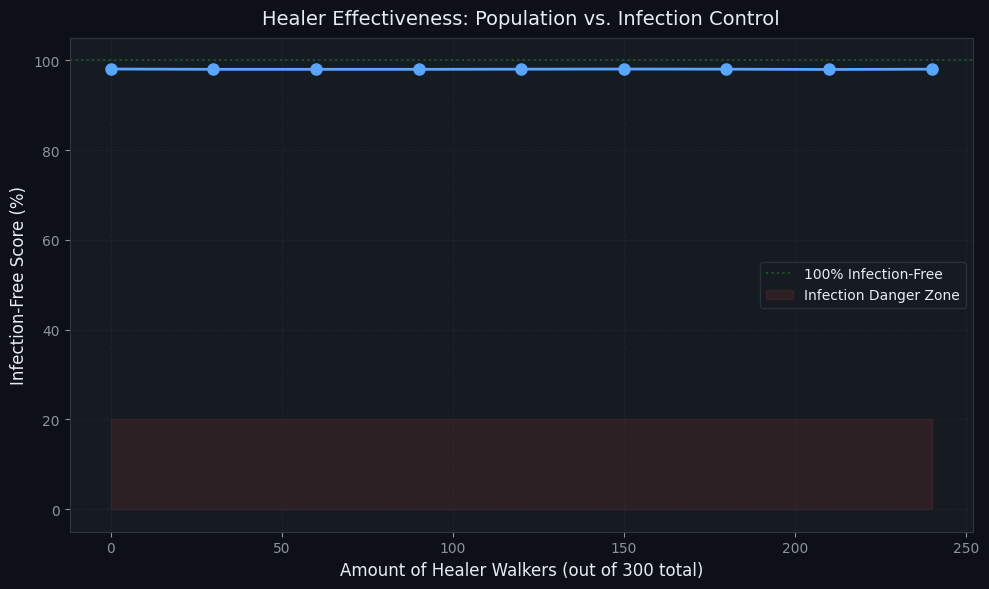

In [4]:
# Configured variables for standalone processing
ratios_to_test = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
healed_results = []
healer_counts = []
total_walkers = n_spawn_points * walkers_per_spawn

print(f"Starting standalone experiment over {len(ratios_to_test)} scenarios...")
print(f"Total Walkers per test: {total_walkers}")

for ratio in ratios_to_test:
    results = run_simulation(
        mask=wound_mask, 
        base_depth_map=initial_depth_map, # ZAKTUALIZOWANO
        start_cells_rc=start_cells_rc, 
        n_steps=1500, 
        snapshot_every=1500,
        healer_ratio=ratio, 
        spread_chance=0.02,
        boost_chance=0.01
    )
    
    final_snap = results[-1]
    total_wound_cells = wound_mask.sum()
    remaining_infected = final_snap['infected'].sum()
    
    percentage = (1 - (remaining_infected / total_wound_cells)) * 100
    healed_results.append(percentage)
    healer_counts.append(int(total_walkers * ratio))
    print(f"Ratio: {ratio:.1f} ({healer_counts[-1]} healers) -> {percentage:.1f}% Score")

# -- Plotting the Results --
plt.figure(figsize=(10, 6))
plt.plot(healer_counts, healed_results, marker='o', linestyle='-', color=_BLUE_WALK, linewidth=2, markersize=8)
plt.title("Healer Effectiveness: Population vs. Infection Control", fontsize=14)
plt.xlabel(f"Amount of Healer Walkers (out of {total_walkers} total)", fontsize=12)
plt.ylabel("Infection-Free Score (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, color=_EDGE)
plt.ylim(-5, 105)
plt.axhline(y=100, color=_GREEN_HLD, linestyle=':', alpha=0.8, label="100% Infection-Free")
plt.fill_between(healer_counts, 0, 20, color=_RED_HOT, alpha=0.1, label="Infection Danger Zone")
plt.legend()
plt.tight_layout()
plt.savefig("healer_efficiency_plot.png")
plt.show()

### Section 3: Head-to-Head Efficiency Comparison (With vs Without Boost)

In [5]:
ratios_for_comparison = np.linspace(0.0, 0.7, 8)
scores_no_boost = []
scores_with_boost = []
all_cells = wound_mask.sum()

print("Running Head-to-Head Evaluation Experiment...")
for ratio in ratios_for_comparison:
    # Evaluated without boosting context
    res_no = run_simulation(wound_mask, start_cells_rc, 500, 500, ratio, 0.04, boost_chance=0.0)
    inf_no = res_no[-1]['infected'].sum()
    scores_no_boost.append((1 - (inf_no / all_cells)) * 100)
    
    # Evaluated with active structural neighborhood boosting
    res_yes = run_simulation(wound_mask, start_cells_rc, 500, 500, ratio, 0.04, boost_chance=0.01)
    inf_yes = res_yes[-1]['infected'].sum()
    scores_with_boost.append((1 - (inf_yes / all_cells)) * 100)
    print(f"Completed processing for baseline Healer Workforce Ratio: {ratio:.2f}")

# -- Visualization Configuration --
plt.figure(figsize=(10, 6))
comparison_counts = ratios_for_comparison * total_walkers

plt.plot(comparison_counts, scores_no_boost, 'o--', color=_RED_HOT, label="Without Healthy Boost")
plt.plot(comparison_counts, scores_with_boost, 'o-', color=_GREEN_HLD, linewidth=2, label="With Healthy Boost (Natural Immunity)")

plt.title("Comparison: The Impact of Natural Immunity on Healer Efficiency", fontsize=14)
plt.xlabel("Amount of Healer Walkers", fontsize=12)
plt.ylabel("Infection-Free Score (%)", fontsize=12)
plt.grid(True, alpha=0.2, color=_TICK)
plt.ylim(-5, 105)
plt.legend()
plt.tight_layout()
plt.show()

Running Head-to-Head Evaluation Experiment...


TypeError: run_simulation() missing 1 required positional argument: 'spread_chance'